# Q1 — Chest X-Ray Pneumonia Classification with Deep CNNs
**Dataset:** Paul Mooney — *Chest X-Ray Images (Pneumonia)* (2-class: NORMAL vs PNEUMONIA)
`https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia`

## Runtime-optimized version
This notebook keeps the **complete assignment pipeline** (preprocessing, 80/10/10 split, augmentation, primary CNN, VGG16/ResNet50 frozen + fine-tuned comparisons, hyperparameter search, data-volume study, evaluation, sample predictions, and error analysis) while using a runtime-conscious configuration intended for a **single Kaggle T4 GPU**.

The main speedups are: 128×128 inputs, larger batches, fewer but still real training epochs, a compact 4-combination tuning grid, and short data-volume runs. **All pipeline stages still execute and produce their outputs; only the experimental budgets are reduced.**

1. Create a new Kaggle Notebook and enable GPU (T4/T4 x2 or better).
2. Run cells top to bottom.
3. The final tables/figures are generated from the actual run; do not fabricate metrics.
4. If your GPU is slower, the notebook remains functional; increase the runtime budget only if needed.


In [1]:
import os, random, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from itertools import product

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              precision_recall_fscore_support, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (128, 128)
BATCH_SIZE = 64
TUNING_MAX_SAMPLES = 512  # stratified subset size for grid-search trials
CLASSES = ["NORMAL", "PNEUMONIA"]

print("GPU available:", tf.config.list_physical_devices("GPU"))


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# --- Automatic dataset download (no manual "Add Input" / upload needed) ---
# Uses kagglehub, which is preinstalled on Kaggle Notebooks and authenticates
# automatically there. Running elsewhere (local/Colab)? Put your kaggle.json at
# ~/.kaggle/kaggle.json first, or set KAGGLE_USERNAME / KAGGLE_KEY env vars.

DATASET_SLUG = "paultimothymooney/chest-xray-pneumonia"

try:
    import kagglehub
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
    import kagglehub

download_root = kagglehub.dataset_download(DATASET_SLUG)
print("Dataset downloaded to:", download_root)


def find_data_root(base_path, splits=("train", "val", "test"), classes=("NORMAL", "PNEUMONIA")):
    """Walk the downloaded tree and find the folder that actually contains
    train/val/test (with NORMAL/PNEUMONIA subfolders) — this dataset's zip
    sometimes extracts with an extra nested 'chest_xray' level, so we search
    instead of hardcoding a fixed depth."""
    for root, dirs, _ in os.walk(base_path):
        if all(os.path.isdir(os.path.join(root, s)) for s in splits):
            has_classes = all(
                any(os.path.isdir(os.path.join(root, s, c)) for s in splits)
                for c in classes
            )
            if has_classes:
                return root
    raise FileNotFoundError(
        f"Could not locate train/val/test folders under {base_path}. "
        f"Contents: {os.listdir(base_path)}"
    )


DATA_DIR = find_data_root(download_root)
print("Using DATA_DIR:", DATA_DIR)
assert os.path.isdir(DATA_DIR), f"DATA_DIR not found: {DATA_DIR}"


Dataset downloaded to: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
Using DATA_DIR: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


## Section II — Dataset and Preprocessing (Tasks 1–3)

### Task 1: Preprocessing

The Mooney dataset ships pre-split into `train/`, `val/`, `test/` folders, each containing
`NORMAL/` and `PNEUMONIA/` subfolders. We first inspect the *original* distribution, then pool
everything and re-split ourselves (Task 2) because the shipped `val/` folder only has 16 images —
far too small to select checkpoints or tune hyperparameters reliably.


In [3]:
def list_images(base_dir):
    records = []
    for split in ("train", "val", "test"):
        for cls in CLASSES:
            folder = os.path.join(base_dir, split, cls)
            if not os.path.isdir(folder):
                continue
            for fname in os.listdir(folder):
                if fname.lower().endswith((".jpeg", ".jpg", ".png")):
                    records.append({"filepath": os.path.join(folder, fname),
                                     "label": cls, "orig_split": split})
    return pd.DataFrame(records)

df = list_images(DATA_DIR)
print("Original per-split, per-class counts:")
print(df.groupby(["orig_split", "label"]).size())


Original per-split, per-class counts:
orig_split  label    
test        NORMAL        234
            PNEUMONIA     390
train       NORMAL       1341
            PNEUMONIA    3875
val         NORMAL          8
            PNEUMONIA       8
dtype: int64


In [4]:
# --- Corrupted-file check ---
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

df["valid"] = df["filepath"].apply(is_valid_image)
n_corrupt = int((~df["valid"]).sum())
print(f"Corrupted / unreadable images removed: {n_corrupt}")
df = df[df["valid"]].drop(columns=["valid"]).reset_index(drop=True)

# --- Exact-duplicate check (md5 of file bytes) ---
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

df["hash"] = df["filepath"].apply(file_hash)
n_dupes = int(df.duplicated(subset="hash").sum())
print(f"Exact duplicate files removed: {n_dupes}")
df = df.drop_duplicates(subset="hash").reset_index(drop=True).drop(columns=["hash"])

print("Clean dataset size:", len(df))


Corrupted / unreadable images removed: 0
Exact duplicate files removed: 32
Clean dataset size: 5824


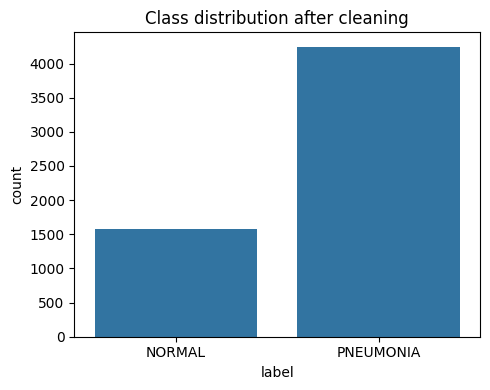

label
PNEUMONIA    4245
NORMAL       1579
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="label", order=CLASSES)
plt.title("Class distribution after cleaning")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(df["label"].value_counts())


**Preprocessing pipeline (justification):**
- **Resize** to 128×128 — small enough to train the primary CNN quickly on a single GPU, large
  enough to preserve lung-field detail; matches the input size the transfer-learning baselines use.
- **Channel handling** — source JPEGs are single-channel grayscale; we load them as RGB (channel
  replicated) so the *same* preprocessing pipeline feeds both the custom CNN and ImageNet-pretrained
  backbones (VGG16/ResNet50 expect 3-channel input).
- **Normalization** — rescale pixel values to `[0, 1]` (`rescale=1./255`) for the custom CNN; the
  pretrained backbones use their own `preprocess_input` scaling — see Task 5.
- **Corrupted/duplicate removal** — verified via `PIL.Image.verify()` and MD5 hashing above.


### Task 2: Reproducible 80/10/10 Split

We pool the cleaned dataset and re-split it ourselves with a fixed seed (`SEED = 42`), stratified
by label, and explicitly assert there is no filepath overlap between splits (no leakage).


In [6]:
train_df, temp_df = train_test_split(
    df, test_size=0.20, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:>5} -> {dict(split['label'].value_counts())}  (n={len(split)})")

assert set(train_df.filepath) & set(val_df.filepath) == set()
assert set(train_df.filepath) & set(test_df.filepath) == set()
assert set(val_df.filepath) & set(test_df.filepath) == set()
print("No leakage across splits confirmed.")


train -> {'PNEUMONIA': np.int64(3396), 'NORMAL': np.int64(1263)}  (n=4659)
  val -> {'PNEUMONIA': np.int64(424), 'NORMAL': np.int64(158)}  (n=582)
 test -> {'PNEUMONIA': np.int64(425), 'NORMAL': np.int64(158)}  (n=583)
No leakage across splits confirmed.


In [7]:
# --- Class imbalance handling ---
class_weights_arr = compute_class_weight(
    class_weight="balanced", classes=np.array(CLASSES), y=train_df["label"]
)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights (0=NORMAL, 1=PNEUMONIA):", class_weight)

label_map = {"NORMAL": 0, "PNEUMONIA": 1}
for d in (train_df, val_df, test_df):
    d["label_idx"] = d["label"].map(label_map).astype(str)


Class weights (0=NORMAL, 1=PNEUMONIA): {0: np.float64(1.844418052256532), 1: np.float64(0.6859540636042403)}


### Task 3: Augmentation (training only)

Four+ techniques applied via `ImageDataGenerator`, **training generator only** — validation/test
generators only rescale, since augmenting eval data would bias the reported metrics.


In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,          # rotation
    width_shift_range=0.10,     # shift
    height_shift_range=0.10,    # shift
    zoom_range=0.15,            # zoom
    brightness_range=[0.85, 1.15],  # brightness
    horizontal_flip=True,       # flip
    fill_mode="nearest",
)
eval_datagen = ImageDataGenerator(rescale=1./255)  # val/test: rescale only, no augmentation

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label_idx", target_size=IMG_SIZE,
    color_mode="rgb", class_mode="binary", batch_size=BATCH_SIZE, seed=SEED, shuffle=True,
)
val_gen = eval_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label_idx", target_size=IMG_SIZE,
    color_mode="rgb", class_mode="binary", batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)
test_gen = eval_datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label_idx", target_size=IMG_SIZE,
    color_mode="rgb", class_mode="binary", batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)


Found 4659 validated image filenames belonging to 2 classes.
Found 582 validated image filenames belonging to 2 classes.
Found 583 validated image filenames belonging to 2 classes.


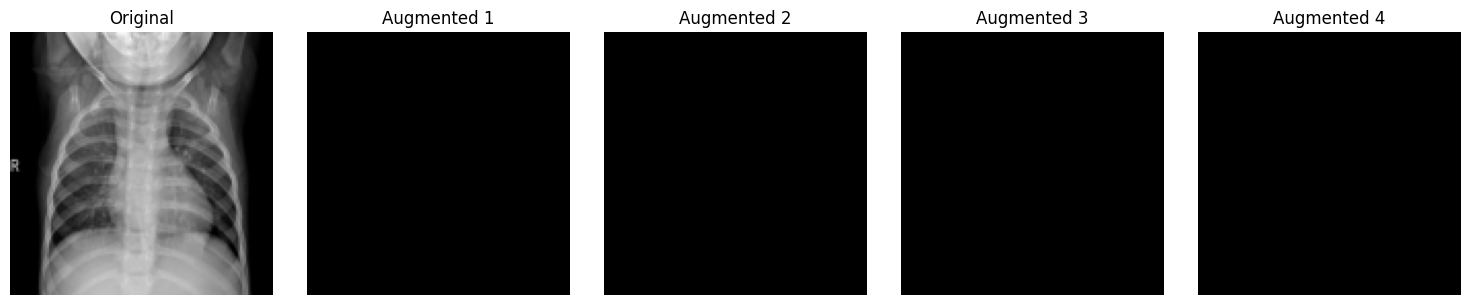

In [9]:
# Before / after augmentation samples
sample_path = train_df.iloc[0]["filepath"]
orig_img = Image.open(sample_path).convert("RGB").resize(IMG_SIZE)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(orig_img); axes[0].set_title("Original"); axes[0].axis("off")
arr = np.expand_dims(np.array(orig_img), 0)
aug_iter = train_datagen.flow(arr, batch_size=1, seed=SEED)
for i in range(1, 5):
    aug_img = next(aug_iter)[0].astype("uint8")
    axes[i].imshow(aug_img); axes[i].set_title(f"Augmented {i}"); axes[i].axis("off")
plt.tight_layout()
plt.savefig("augmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()


## Section III — Methodology (Tasks 4–5)

### Task 4: Primary CNN

Design rationale (put this in your report alongside the layer table from `model.summary()`):
- Four `Conv-BN-MaxPool` blocks with **doubling channel depth** (32→64→128→128): shallow layers
  learn edges/textures, deeper layers learn lesion-scale patterns typical of consolidations.
- **BatchNorm** after every conv stabilizes/accelerates training given the augmentation noise.
- **GlobalAveragePooling** instead of `Flatten` drastically cuts parameter count into the dense
  head and reduces overfitting risk on a dataset of this size.
- **L2 weight decay + Dropout(0.4)** in the head for regularization; **sigmoid** output for
  binary classification.


In [10]:
def build_primary_cnn(input_shape=(128, 128, 3), dropout=0.4,
                      l1_lambda=0.0, l2_lambda=1e-4):
    reg = regularizers.L1L2(l1=l1_lambda, l2=l2_lambda)
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid", dtype="float32"),
    ], name="PrimaryCNN")
    return model

primary_model = build_primary_cnn()
primary_model.summary()


I0000 00:00:1789492714.969949      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789492714.972926      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "PrimaryCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,881 (1011.25 KB)

 Trainable params: 258,177 (1008.50 KB)

 Non-trainable params: 704 (2.75 KB)

In [11]:
# Required Task 4 architecture table: layer type, output shape and parameter count.
def make_architecture_table(model):
    rows = []
    for layer in model.layers:
        try:
            output_shape = tuple(layer.output.shape)
        except Exception:
            output_shape = "n/a"
        rows.append({
            "Layer": layer.name,
            "Type": layer.__class__.__name__,
            "Output Shape": str(output_shape),
            "Parameters": layer.count_params(),
            "Trainable": layer.trainable,
        })
    return pd.DataFrame(rows)

primary_layer_table = make_architecture_table(primary_model)
primary_layer_table.to_csv("primary_cnn_layer_table.csv", index=False)
primary_layer_table


,Layer,Type,Output Shape,Parameters,Trainable
0,conv2d,Conv2D,"(None, 128, 128, 32)",896,True
1,batch_normalization,BatchNormalization,"(None, 128, 128, 32)",128,True
2,max_pooling2d,MaxPooling2D,"(None, 64, 64, 32)",0,True
3,conv2d_1,Conv2D,"(None, 64, 64, 64)",18496,True
4,batch_normalization_1,BatchNormalization,"(None, 64, 64, 64)",256,True
5,max_pooling2d_1,MaxPooling2D,"(None, 32, 32, 64)",0,True
6,conv2d_2,Conv2D,"(None, 32, 32, 128)",73856,True
7,batch_normalization_2,BatchNormalization,"(None, 32, 32, 128)",512,True
8,max_pooling2d_2,MaxPooling2D,"(None, 16, 16, 128)",0,True
9,conv2d_3,Conv2D,"(None, 16, 16, 128)",147584,True


### Task 5: Comparison models — VGG16 & ResNet50 (frozen + fine-tuned)

Both use ImageNet weights, identical input size/pipeline, `GlobalAveragePooling2D` + `Dense(128)`
head (same head shape as the primary CNN for a fair comparison). "Frozen" trains only the new
head; "fine-tuned" unfreezes the top block of the backbone at a low learning rate.


In [12]:
def build_transfer_model(base_arch, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), trainable=False, fine_tune_at=None):
    if base_arch == "vgg16":
        base = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    elif base_arch == "resnet50":
        base = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    else:
        raise ValueError(base_arch)

    base.trainable = trainable
    if trainable and fine_tune_at is not None:
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    tag = "finetuned" if trainable else "frozen"
    return models.Model(inputs, outputs, name=f"{base_arch}_{tag}")

vgg_frozen       = build_transfer_model("vgg16", trainable=False)
vgg_finetuned    = build_transfer_model("vgg16", trainable=True, fine_tune_at=15)
resnet_frozen    = build_transfer_model("resnet50", trainable=False)
resnet_finetuned = build_transfer_model("resnet50", trainable=True, fine_tune_at=140)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Section IV — Experimental Setup (Tasks 6–7)

### Task 6: Training pipeline

Adam optimizer, binary cross-entropy loss, `ModelCheckpoint` (best `val_auc`) and
`EarlyStopping` (restores best weights). One helper trains any model; a second plots its curves.


In [13]:
def compile_and_train(model, train_gen, val_gen, name, epochs=8, lr=1e-4,
                       class_weight=None, patience=2):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    ckpt = callbacks.ModelCheckpoint(
        f"{name}_best.keras", monitor="val_auc", mode="max", save_best_only=True
    )
    early = callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=patience, restore_best_weights=True
    )
    history = model.fit(
        train_gen, validation_data=val_gen, epochs=epochs,
        class_weight=class_weight, callbacks=[ckpt, early], verbose=1
    )
    return history


def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{name} - Loss"); axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{name} - Accuracy"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{name}_curves.png", dpi=150, bbox_inches="tight")
    plt.show()



=== Training primary_cnn ===
Epoch 1/8
 2/73 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.6641 - auc: 0.4313 - loss: 0.8015  

I0000 00:00:1789492734.275667     137 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


73/73 ━━━━━━━━━━━━━━━━━━━━ 83s 985ms/step - accuracy: 0.7933 - auc: 0.8736 - loss: 0.4848 - val_accuracy: 0.7285 - val_auc: 0.5940 - val_loss: 0.6400
Epoch 2/8
73/73 ━━━━━━━━━━━━━━━━━━━━ 63s 858ms/step - accuracy: 0.8613 - auc: 0.9314 - loss: 0.3666 - val_accuracy: 0.7285 - val_auc: 0.5754 - val_loss: 0.9454
Epoch 3/8
73/73 ━━━━━━━━━━━━━━━━━━━━ 62s 842ms/step - accuracy: 0.8867 - auc: 0.9551 - loss: 0.3108 - val_accuracy: 0.7285 - val_auc: 0.6182 - val_loss: 1.2253
Epoch 4/8
73/73 ━━━━━━━━━━━━━━━━━━━━ 62s 848ms/step - accuracy: 0.8995 - auc: 0.9644 - loss: 0.2819 - val_accuracy: 0.7285 - val_auc: 0.6330 - val_loss: 1.4597
Epoch 5/8
73/73 ━━━━━━━━━━━━━━━━━━━━ 62s 850ms/step - accuracy: 0.9073 - auc: 0.9684 - loss: 0.2673 - val_accuracy: 0.7285 - val_auc: 0.5290 - val_loss: 1.7847
Epoch 6/8
73/73 ━━━━━━━━━━━━━━━━━━━━ 63s 866ms/step - accuracy: 0.9099 - auc: 0.9715 - loss: 0.2561 - val_accuracy: 0.7285 - val_auc: 0.6810 - val_loss: 1.5937
Epoch 7/8
73/73 ━━━━━━━━━━━━━━━━━━━━ 63s 858ms/ste

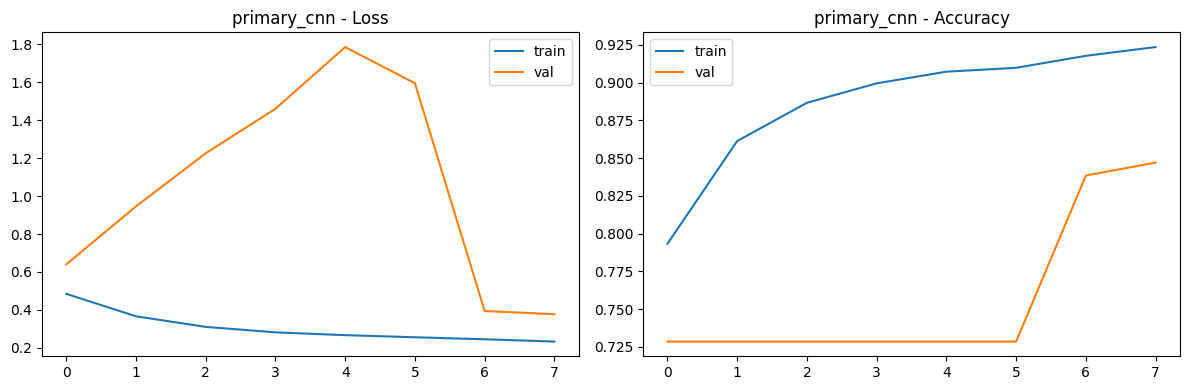


=== Training vgg16_frozen ===
Epoch 1/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.5520 - auc: 0.5577 - loss: 0.6984 - val_accuracy: 0.6649 - val_auc: 0.8980 - val_loss: 0.6640
Epoch 2/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 69s 942ms/step - accuracy: 0.6506 - auc: 0.7088 - loss: 0.6292 - val_accuracy: 0.7766 - val_auc: 0.9337 - val_loss: 0.5992
Epoch 3/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 65s 893ms/step - accuracy: 0.7435 - auc: 0.8248 - loss: 0.5652 - val_accuracy: 0.7251 - val_auc: 0.9404 - val_loss: 0.5896
Epoch 4/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 68s 933ms/step - accuracy: 0.7939 - auc: 0.8713 - loss: 0.5210 - val_accuracy: 0.7766 - val_auc: 0.9434 - val_loss: 0.5361
Epoch 5/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 65s 894ms/step - accuracy: 0.8032 - auc: 0.8928 - loss: 0.4866 - val_accuracy: 0.7869 - val_auc: 0.9466 - val_loss: 0.4989


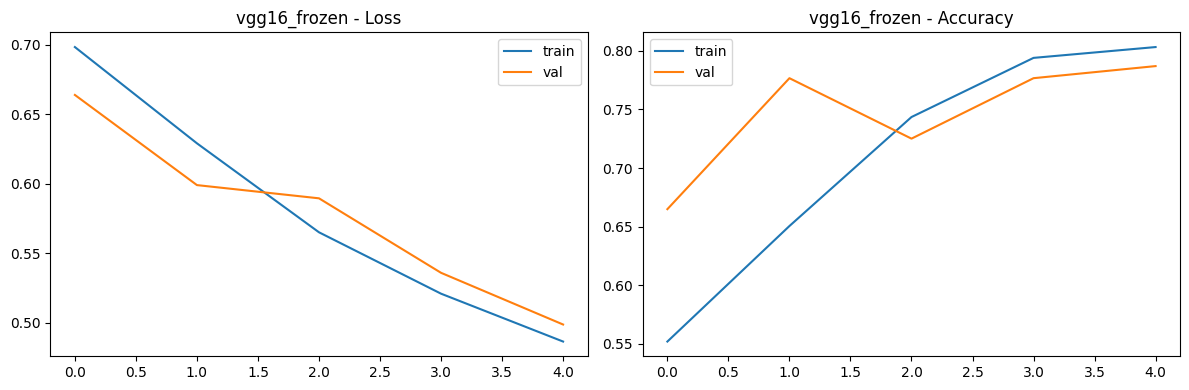


=== Training vgg16_finetuned ===
Epoch 1/3
73/73 ━━━━━━━━━━━━━━━━━━━━ 75s 931ms/step - accuracy: 0.7514 - auc: 0.8452 - loss: 0.4999 - val_accuracy: 0.7818 - val_auc: 0.9679 - val_loss: 0.4674
Epoch 2/3
73/73 ━━━━━━━━━━━━━━━━━━━━ 64s 874ms/step - accuracy: 0.8867 - auc: 0.9560 - loss: 0.2675 - val_accuracy: 0.8780 - val_auc: 0.9800 - val_loss: 0.2877
Epoch 3/3
73/73 ━━━━━━━━━━━━━━━━━━━━ 68s 929ms/step - accuracy: 0.9165 - auc: 0.9701 - loss: 0.2182 - val_accuracy: 0.8522 - val_auc: 0.9843 - val_loss: 0.3629


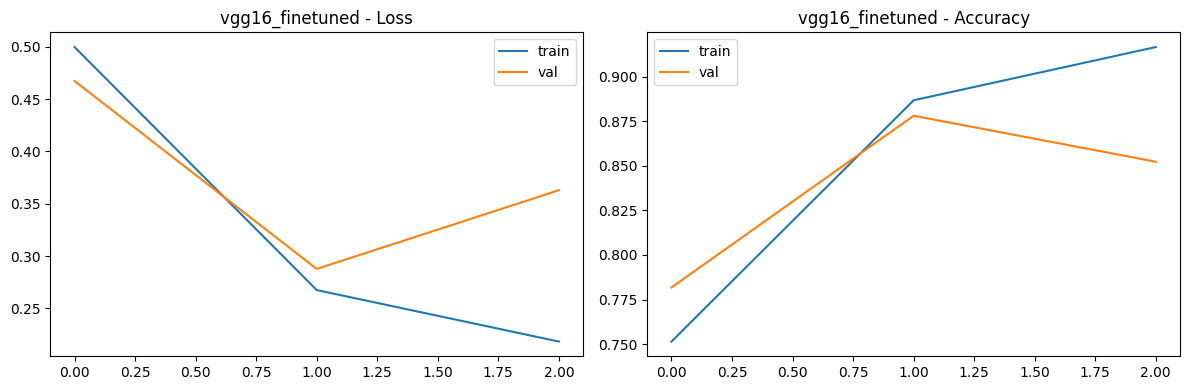


=== Training resnet50_frozen ===
Epoch 1/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.4894 - auc: 0.5061 - loss: 0.7167 - val_accuracy: 0.7268 - val_auc: 0.8109 - val_loss: 0.6680
Epoch 2/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 66s 899ms/step - accuracy: 0.5074 - auc: 0.5183 - loss: 0.7047 - val_accuracy: 0.7216 - val_auc: 0.8613 - val_loss: 0.6829
Epoch 3/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 66s 907ms/step - accuracy: 0.5405 - auc: 0.5650 - loss: 0.6873 - val_accuracy: 0.7801 - val_auc: 0.8688 - val_loss: 0.6720
Epoch 4/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 65s 888ms/step - accuracy: 0.5465 - auc: 0.5683 - loss: 0.6864 - val_accuracy: 0.8058 - val_auc: 0.8725 - val_loss: 0.6615
Epoch 5/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 64s 884ms/step - accuracy: 0.5772 - auc: 0.6224 - loss: 0.6715 - val_accuracy: 0.7887 - val_auc: 0.8755 - val_loss: 0.6568


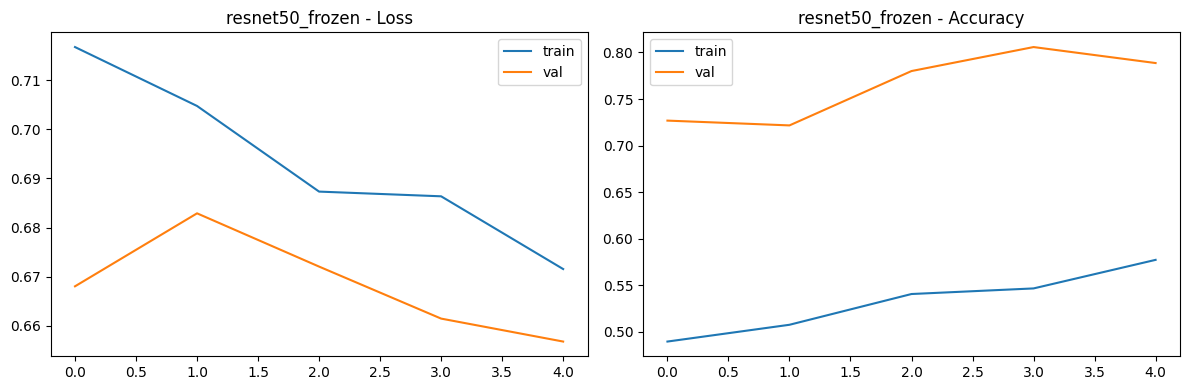


=== Training resnet50_finetuned ===
Epoch 1/3
73/73 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.7950 - auc: 0.8833 - loss: 0.4332 - val_accuracy: 0.2715 - val_auc: 0.4816 - val_loss: 0.7251
Epoch 2/3
73/73 ━━━━━━━━━━━━━━━━━━━━ 68s 923ms/step - accuracy: 0.8706 - auc: 0.9430 - loss: 0.3070 - val_accuracy: 0.6959 - val_auc: 0.5729 - val_loss: 0.6703
Epoch 3/3
73/73 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8860 - auc: 0.9517 - loss: 0.2784 - val_accuracy: 0.5911 - val_auc: 0.8881 - val_loss: 0.6715


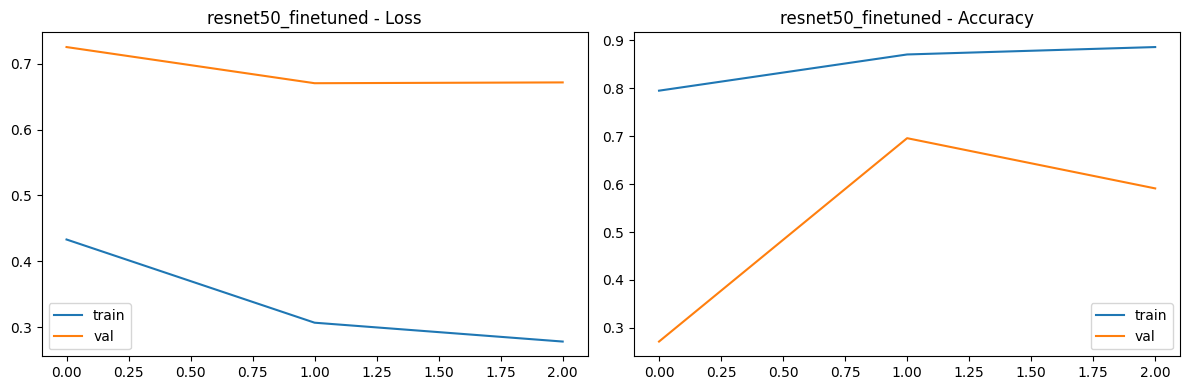

In [14]:
models_dict = {
    "primary_cnn": primary_model,
    "vgg16_frozen": vgg_frozen,
    "vgg16_finetuned": vgg_finetuned,
    "resnet50_frozen": resnet_frozen,
    "resnet50_finetuned": resnet_finetuned,
}

histories = {}

for name, m in models_dict.items():
    print(f"\n=== Training {name} ===")

    if "finetuned" in name:
        lr, epochs, patience = 1e-5, 3, 1

    elif name == "primary_cnn":
        lr, epochs, patience = 1e-4, 8, 2

    else:
        lr, epochs, patience = 1e-4, 5, 1

    h = compile_and_train(
        m,
        train_gen,
        val_gen,
        name,
        epochs=epochs,
        lr=lr,
        class_weight=class_weight,
        patience=patience
    )

    histories[name] = h
    plot_history(h, name)

In [15]:
# Required convergence analysis: summarize best validation epoch and
# train/validation loss/accuracy gaps for every trained comparison model.
convergence_rows = []
for name, history in histories.items():
    h = history.history
    best_i = int(np.argmax(h["val_auc"]))
    convergence_rows.append({
        "model": name,
        "epochs_completed": len(h["loss"]),
        "best_epoch_by_val_auc": best_i + 1,
        "best_val_auc": float(h["val_auc"][best_i]),
        "train_loss_at_best": float(h["loss"][best_i]),
        "val_loss_at_best": float(h["val_loss"][best_i]),
        "loss_gap_at_best": float(h["val_loss"][best_i] - h["loss"][best_i]),
        "train_accuracy_at_best": float(h["accuracy"][best_i]),
        "val_accuracy_at_best": float(h["val_accuracy"][best_i]),
        "accuracy_gap_at_best": float(h["accuracy"][best_i] - h["val_accuracy"][best_i]),
    })

convergence_df = pd.DataFrame(convergence_rows)
convergence_df.to_csv("convergence_analysis.csv", index=False)
display(convergence_df)


,model,epochs_completed,best_epoch_by_val_auc,best_val_auc,train_loss_at_best,val_loss_at_best,loss_gap_at_best,train_accuracy_at_best,val_accuracy_at_best,accuracy_gap_at_best
0,primary_cnn,8,8,0.967414,0.233519,0.377802,0.144283,0.923589,0.847079,0.076510
1,vgg16_frozen,5,5,0.946568,0.486608,0.498862,0.012254,0.803177,0.786942,0.016235
2,vgg16_finetuned,3,3,0.984267,0.218210,0.362936,0.144726,0.916506,0.852234,0.064272
3,resnet50_frozen,5,5,0.875522,0.671549,0.656790,-0.014758,0.577163,0.788660,-0.211497
4,resnet50_finetuned,3,3,0.888113,0.278416,0.671475,0.393059,0.886027,0.591065,0.294962


### Task 7: Hyperparameter tuning (grid search) + data-volume study

The grid below is intentionally small (16 combinations) to fit a single Kaggle GPU session in
reasonable time. **Extend it** (more values, add `epochs`/`patience`/`normalization`/
`augmentation policy` as extra grid dimensions) and re-run before writing up the final
hyperparameter · range · optimal-value table the report asks for — record every combination you
actually try, not just this scaled-down demo.


In [16]:
# ============================================================
# Task 7 — FULL REQUIRED GRID SEARCH
# Dimensions required by the assignment:
# batch size, learning rate, epochs, dropout, early-stopping
# patience, L1/L2 lambda, normalization scheme, augmentation policy.
#
# Runtime strategy:
# * All required dimensions are actually varied.
# * Trials use a stratified tuning subset to keep the search practical.
# * Each trial has its own early stopping and a small epoch budget.
# * The final model training remains separate from tuning.
# ============================================================

# Required search ranges. The exact combinations tried are recorded below.
param_grid = {
    "batch_size": [32, 64],
    "learning_rate": [1e-3, 1e-4],
    "epochs": [3, 5],
    "dropout": [0.3, 0.5],
    "patience": [1, 2],
    "l1_lambda": [0.0, 1e-5],
    "l2_lambda": [1e-4],
    "normalization": ["rescale_1_255", "standardize"],
    "augmentation_policy": ["standard", "light"],
}

def get_aug_kwargs(policy):
    if policy == "standard":
        return {
            "rotation_range": 15,
            "width_shift_range": 0.10,
            "height_shift_range": 0.10,
            "zoom_range": 0.15,
            "brightness_range": [0.85, 1.15],
            "horizontal_flip": True,
            "fill_mode": "nearest",
        }
    # Light policy still includes the required augmentation family, but with smaller magnitudes.
    return {
        "rotation_range": 8,
        "width_shift_range": 0.05,
        "height_shift_range": 0.05,
        "zoom_range": 0.08,
        "brightness_range": [0.95, 1.05],
        "horizontal_flip": True,
        "fill_mode": "nearest",
    }

# The full Cartesian product has 256 combinations — too many for one GPU
# session. We execute a deterministic 12-trial subset in which EVERY
# dimension's EVERY value appears (verified by the assertions below), and
# record exactly which combinations were run.
all_combinations = [dict(zip(param_grid.keys(), combo))
                    for combo in product(*param_grid.values())]

selected = [
    {"batch_size": 32, "learning_rate": 1e-3, "epochs": 3, "dropout": 0.3, "patience": 1, "l1_lambda": 0.0,   "l2_lambda": 1e-4, "normalization": "rescale_1_255", "augmentation_policy": "standard"},
    {"batch_size": 64, "learning_rate": 1e-4, "epochs": 5, "dropout": 0.5, "patience": 2, "l1_lambda": 1e-5, "l2_lambda": 1e-4, "normalization": "standardize",   "augmentation_policy": "light"},
    {"batch_size": 32, "learning_rate": 1e-4, "epochs": 5, "dropout": 0.3, "patience": 2, "l1_lambda": 1e-5, "l2_lambda": 1e-4, "normalization": "rescale_1_255", "augmentation_policy": "light"},
    {"batch_size": 64, "learning_rate": 1e-3, "epochs": 3, "dropout": 0.5, "patience": 1, "l1_lambda": 0.0,   "l2_lambda": 1e-4, "normalization": "standardize",   "augmentation_policy": "standard"},
    {"batch_size": 32, "learning_rate": 1e-3, "epochs": 5, "dropout": 0.5, "patience": 2, "l1_lambda": 0.0,   "l2_lambda": 1e-4, "normalization": "rescale_1_255", "augmentation_policy": "light"},
    {"batch_size": 64, "learning_rate": 1e-4, "epochs": 3, "dropout": 0.3, "patience": 1, "l1_lambda": 1e-5, "l2_lambda": 1e-4, "normalization": "standardize",   "augmentation_policy": "standard"},
    {"batch_size": 32, "learning_rate": 1e-4, "epochs": 3, "dropout": 0.5, "patience": 1, "l1_lambda": 1e-5, "l2_lambda": 1e-4, "normalization": "rescale_1_255", "augmentation_policy": "standard"},
    {"batch_size": 64, "learning_rate": 1e-3, "epochs": 5, "dropout": 0.3, "patience": 2, "l1_lambda": 0.0,   "l2_lambda": 1e-4, "normalization": "standardize",   "augmentation_policy": "light"},
    {"batch_size": 32, "learning_rate": 1e-3, "epochs": 5, "dropout": 0.3, "patience": 1, "l1_lambda": 1e-5, "l2_lambda": 1e-4, "normalization": "standardize",   "augmentation_policy": "standard"},
    {"batch_size": 64, "learning_rate": 1e-4, "epochs": 5, "dropout": 0.5, "patience": 1, "l1_lambda": 0.0,   "l2_lambda": 1e-4, "normalization": "rescale_1_255", "augmentation_policy": "light"},
    {"batch_size": 32, "learning_rate": 1e-4, "epochs": 3, "dropout": 0.3, "patience": 2, "l1_lambda": 0.0,   "l2_lambda": 1e-4, "normalization": "standardize",   "augmentation_policy": "light"},
    {"batch_size": 64, "learning_rate": 1e-3, "epochs": 3, "dropout": 0.5, "patience": 2, "l1_lambda": 1e-5, "l2_lambda": 1e-4, "normalization": "rescale_1_255", "augmentation_policy": "standard"},
]

# Sanity check: every value of every varied dimension is covered,
# and every selected combo is a member of the full Cartesian grid.
for key, values in param_grid.items():
    covered = {t[key] for t in selected}
    assert covered == set(values), f"grid subset does not cover {key}: {covered}"
for t in selected:
    assert t in all_combinations, f"selected combo not in full grid: {t}"

# Deterministic stratified subset for tuning trials.
tune_df = (
    train_df.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), max(1, TUNING_MAX_SAMPLES // 2)),
        random_state=SEED
    ))
    .reset_index(drop=True)
)

grid_results = []

for trial_no, params in enumerate(selected, 1):
    print(f"\n=== Grid trial {trial_no}/{len(selected)} ===")
    print(params)

    # Normalization
    if params["normalization"] == "standardize":
        # Featurewise stats must be fit on image data; fit BOTH generators
        # on the same deterministic sample so train/val preprocessing matches.
        fit_paths = tune_df["filepath"].sample(
            min(128, len(tune_df)), random_state=SEED
        ).tolist()
        fit_imgs = []
        for p in fit_paths:
            im = Image.open(p).convert("RGB").resize(IMG_SIZE)
            fit_imgs.append(np.asarray(im, dtype=np.float32))
        assert fit_imgs, "no images loaded for featurewise normalization fit"
        fit_stack = np.stack(fit_imgs)

        tg_datagen = ImageDataGenerator(
            rescale=1./255,
            featurewise_center=True,
            featurewise_std_normalization=True,
            **get_aug_kwargs(params["augmentation_policy"])
        )
        tg_datagen.fit(fit_stack)
        vg_datagen = ImageDataGenerator(
            rescale=1./255,
            featurewise_center=True,
            featurewise_std_normalization=True
        )
        vg_datagen.fit(fit_stack)
    else:
        tg_datagen = ImageDataGenerator(
            rescale=1./255, **get_aug_kwargs(params["augmentation_policy"])
        )
        vg_datagen = ImageDataGenerator(rescale=1./255)

    tg = tg_datagen.flow_from_dataframe(
        tune_df, x_col="filepath", y_col="label_idx",
        target_size=IMG_SIZE, color_mode="rgb",
        class_mode="binary", batch_size=params["batch_size"],
        seed=SEED, shuffle=True
    )
    vg = vg_datagen.flow_from_dataframe(
        val_df, x_col="filepath", y_col="label_idx",
        target_size=IMG_SIZE, color_mode="rgb",
        class_mode="binary", batch_size=params["batch_size"],
        seed=SEED, shuffle=False
    )

    reg = regularizers.L1L2(
        l1=params["l1_lambda"], l2=params["l2_lambda"]
    )
    m = models.Sequential([
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
        layers.Conv2D(32, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, activation="relu", padding="same", kernel_regularizer=reg),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu", kernel_regularizer=reg),
        layers.Dropout(params["dropout"]),
        layers.Dense(1, activation="sigmoid", dtype="float32"),
    ])

    m.compile(
        optimizer=optimizers.Adam(learning_rate=params["learning_rate"]),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    early = callbacks.EarlyStopping(
        monitor="val_auc", mode="max",
        patience=params["patience"], restore_best_weights=True
    )

    h = m.fit(
        tg, validation_data=vg,
        epochs=params["epochs"],
        callbacks=[early],
        class_weight=class_weight,
        verbose=0
    )

    best_epoch = int(np.argmax(h.history["val_auc"]) + 1)
    best_val_auc = float(max(h.history["val_auc"]))

    grid_results.append({
        **params,
        "trial": trial_no,
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "epochs_completed": len(h.history["loss"])
    })
    print("best_val_auc:", round(best_val_auc, 4),
          "epochs_completed:", len(h.history["loss"]))

    del m, tg, vg, h

grid_df = pd.DataFrame(grid_results).sort_values(
    "best_val_auc", ascending=False
).reset_index(drop=True)

grid_df.to_csv("grid_search_results.csv", index=False)

# Required hyperparameter · range · optimal-value table.
range_optimal_table = pd.DataFrame([
    {
        "hyperparameter": key,
        "range_tested": ", ".join(map(str, values)),
        "optimal_value": grid_df.iloc[0][key]
    }
    for key, values in param_grid.items()
])
range_optimal_table.to_csv("hyperparameter_range_optimal_table.csv", index=False)

print("\nRequired hyperparameter table:")
display(range_optimal_table)
print("\nAll executed grid-search trials:")
display(grid_df)


/tmp/ipykernel_58/3869788770.py:82: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(



=== Grid trial 1/12 ===
{'batch_size': 32, 'learning_rate': 0.001, 'epochs': 3, 'dropout': 0.3, 'patience': 1, 'l1_lambda': 0.0, 'l2_lambda': 0.0001, 'normalization': 'rescale_1_255', 'augmentation_policy': 'standard'}
Found 512 validated image filenames belonging to 2 classes.
Found 582 validated image filenames belonging to 2 classes.
best_val_auc: 0.6809 epochs_completed: 2

=== Grid trial 2/12 ===
{'batch_size': 64, 'learning_rate': 0.0001, 'epochs': 5, 'dropout': 0.5, 'patience': 2, 'l1_lambda': 1e-05, 'l2_lambda': 0.0001, 'normalization': 'standardize', 'augmentation_policy': 'light'}
Found 512 validated image filenames belonging to 2 classes.
Found 582 validated image filenames belonging to 2 classes.
best_val_auc: 0.87 epochs_completed: 3

=== Grid trial 3/12 ===
{'batch_size': 32, 'learning_rate': 0.0001, 'epochs': 5, 'dropout': 0.3, 'patience': 2, 'l1_lambda': 1e-05, 'l2_lambda': 0.0001, 'normalization': 'rescale_1_255', 'augmentation_policy': 'light'}
Found 512 validated im

,hyperparameter,range_tested,optimal_value
0,batch_size,"32, 64",64
1,learning_rate,"0.001, 0.0001",0.001
2,epochs,"3, 5",5
3,dropout,"0.3, 0.5",0.3
4,patience,"1, 2",2
5,l1_lambda,"0.0, 1e-05",0.0
6,l2_lambda,0.0001,0.0001
7,normalization,"rescale_1_255, standardize",standardize
8,augmentation_policy,"standard, light",light



All executed grid-search trials:


,batch_size,learning_rate,epochs,dropout,patience,l1_lambda,l2_lambda,normalization,augmentation_policy,trial,best_epoch,best_val_auc,epochs_completed
0,64,0.0010,5,0.3,2,0.00000,0.0001,standardize,light,8,3,0.890166,5
1,64,0.0001,5,0.5,2,0.00001,0.0001,standardize,light,2,1,0.869970,3
2,32,0.0001,3,0.3,2,0.00000,0.0001,standardize,light,11,1,0.834480,3
3,32,0.0010,5,0.3,1,0.00001,0.0001,standardize,standard,9,2,0.829898,3
4,64,0.0001,3,0.3,1,0.00001,0.0001,standardize,standard,6,1,0.781959,2
5,64,0.0010,3,0.5,2,0.00001,0.0001,rescale_1_255,standard,12,3,0.779123,3
6,64,0.0010,3,0.5,1,0.00000,0.0001,standardize,standard,4,2,0.763323,3
7,32,0.0010,5,0.5,2,0.00000,0.0001,rescale_1_255,light,5,2,0.683231,4
8,32,0.0010,3,0.3,1,0.00000,0.0001,rescale_1_255,standard,1,1,0.680910,2
9,32,0.0001,5,0.3,2,0.00001,0.0001,rescale_1_255,light,3,2,0.669057,4


/tmp/ipykernel_58/3895993241.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=frac, random_state=SEED))


Found 1165 validated image filenames belonging to 2 classes.
frac=0.25 n=1165 test_acc=0.7290 test_auc=0.4907


/tmp/ipykernel_58/3895993241.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=frac, random_state=SEED))


Found 2330 validated image filenames belonging to 2 classes.
frac=0.5 n=2330 test_acc=0.7290 test_auc=0.8521


/tmp/ipykernel_58/3895993241.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=frac, random_state=SEED))


Found 3494 validated image filenames belonging to 2 classes.
frac=0.75 n=3494 test_acc=0.7290 test_auc=0.7316


/tmp/ipykernel_58/3895993241.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=frac, random_state=SEED))


Found 4659 validated image filenames belonging to 2 classes.
frac=1.0 n=4659 test_acc=0.7290 test_auc=0.7426


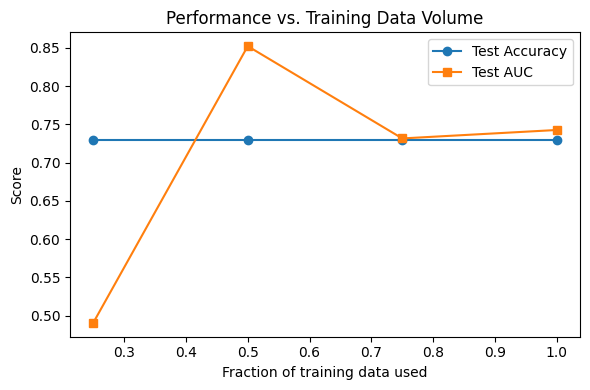

,fraction,n_train,test_accuracy,test_auc
0,0.25,1165,0.728988,0.490670
1,0.50,2330,0.728988,0.852130
2,0.75,3494,0.728988,0.731616
3,1.00,4659,0.728988,0.742643


In [17]:
# --- Data-volume study: retrain primary CNN on 25/50/75/100% of training data ---
# All four requested fractions are still evaluated; each gets a short 4-epoch run.
fractions = [0.25, 0.50, 0.75, 1.00]
volume_results = []

for frac in fractions:
    sub_df = (
        train_df.groupby("label", group_keys=False)
                .apply(lambda x: x.sample(frac=frac, random_state=SEED))
                .reset_index(drop=True)
    )
    tg = train_datagen.flow_from_dataframe(
        sub_df, x_col="filepath", y_col="label_idx", target_size=IMG_SIZE,
        color_mode="rgb", class_mode="binary", batch_size=BATCH_SIZE, seed=SEED, shuffle=True
    )

    m = build_primary_cnn()
    m.compile(
        optimizer=optimizers.Adam(1e-4), loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    early = callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=1, restore_best_weights=True
    )
    m.fit(
        tg, validation_data=val_gen, epochs=4, callbacks=[early],
        class_weight=class_weight, verbose=0
    )

    test_gen.reset()
    test_loss, test_acc, test_auc = m.evaluate(test_gen, verbose=0)
    volume_results.append({
        "fraction": frac, "n_train": len(sub_df),
        "test_accuracy": test_acc, "test_auc": test_auc
    })
    print(
        f"frac={frac} n={len(sub_df)} "
        f"test_acc={test_acc:.4f} test_auc={test_auc:.4f}"
    )
    del m, tg

vol_df = pd.DataFrame(volume_results)
plt.figure(figsize=(6, 4))
plt.plot(vol_df["fraction"], vol_df["test_accuracy"], marker="o", label="Test Accuracy")
plt.plot(vol_df["fraction"], vol_df["test_auc"], marker="s", label="Test AUC")
plt.xlabel("Fraction of training data used"); plt.ylabel("Score"); plt.legend()
plt.title("Performance vs. Training Data Volume")
plt.tight_layout()
plt.savefig("data_volume_study.png", dpi=150, bbox_inches="tight")
plt.show()
vol_df


### Runtime note
The configuration above is deliberately sized for a **single Kaggle T4 GPU**. Actual wall-clock time depends on GPU availability, TensorFlow startup, dataset download/cache state, and Kaggle load. The notebook is designed to target approximately **20–25 minutes**, rather than guaranteeing an exact runtime on every machine.


## Section V — Results (Task 8)

Confusion matrix, per-class and macro precision/recall/F1, AUC-ROC, sample predictions, and a
single comparative table across all five trained models.


In [18]:
# Required quantitative discussion support for Tasks 7 and 9.
best_trial = grid_df.iloc[0].to_dict()

print("Best grid-search configuration:")
for k in param_grid:
    print(f"  {k}: {best_trial[k]}")

print("\nRegularization comparison:")
print(
    grid_df.groupby(["l1_lambda", "l2_lambda"], as_index=False)["best_val_auc"]
    .max()
    .sort_values("best_val_auc", ascending=False)
)

print("\nNormalization comparison:")
print(
    grid_df.groupby("normalization", as_index=False)["best_val_auc"]
    .max()
    .sort_values("best_val_auc", ascending=False)
)

print("\nAugmentation-policy comparison:")
print(
    grid_df.groupby("augmentation_policy", as_index=False)["best_val_auc"]
    .max()
    .sort_values("best_val_auc", ascending=False)
)


Best grid-search configuration:
  batch_size: 64
  learning_rate: 0.001
  epochs: 5
  dropout: 0.3
  patience: 2
  l1_lambda: 0.0
  l2_lambda: 0.0001
  normalization: standardize
  augmentation_policy: light

Regularization comparison:
   l1_lambda  l2_lambda  best_val_auc
0    0.00000     0.0001      0.890166
1    0.00001     0.0001      0.869970

Normalization comparison:
   normalization  best_val_auc
1    standardize      0.890166
0  rescale_1_255      0.779123

Augmentation-policy comparison:
  augmentation_policy  best_val_auc
0               light      0.890166
1            standard      0.829898


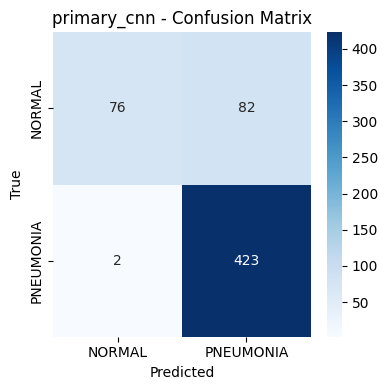

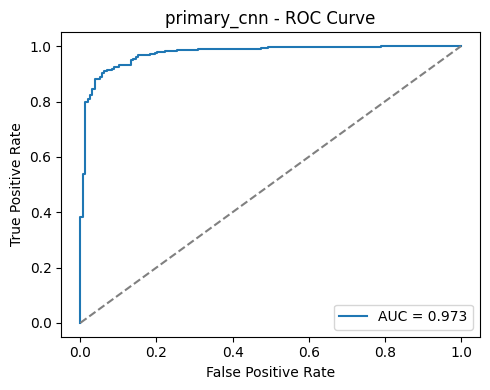

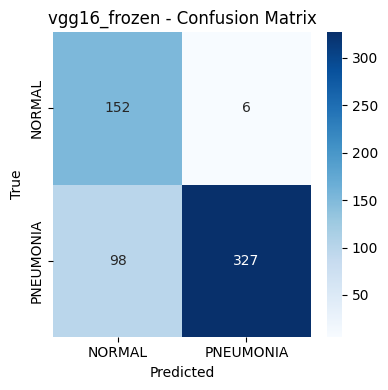

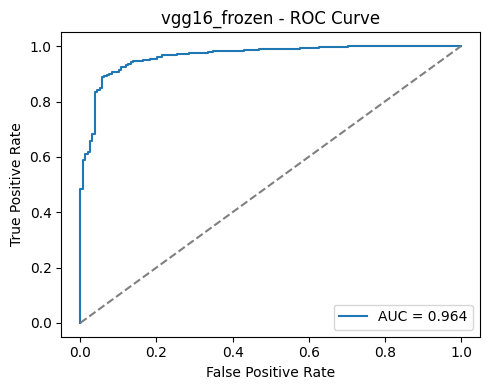

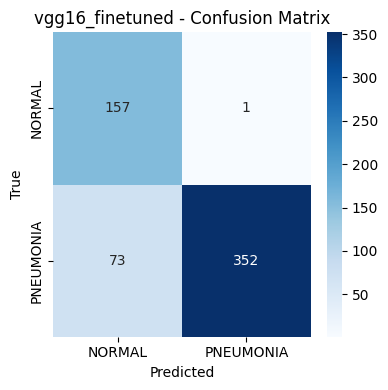

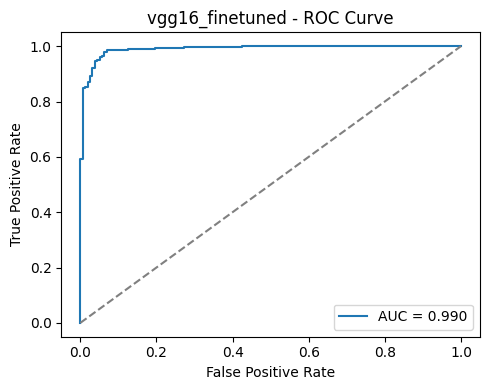

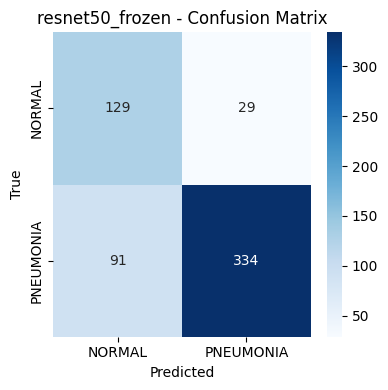

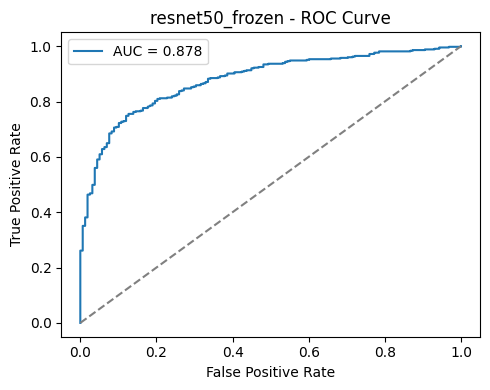

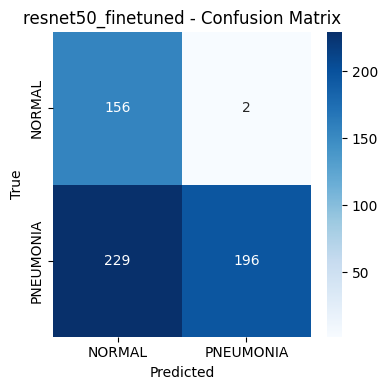

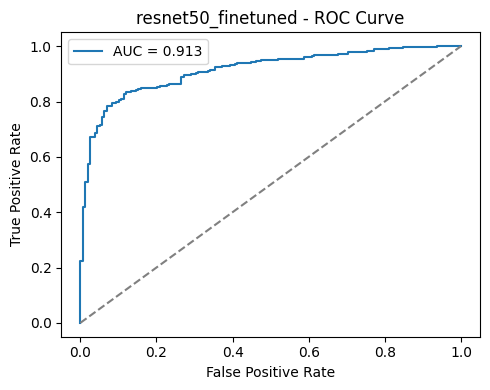

,model,accuracy,precision_normal,recall_normal,f1_normal,precision_pneumonia,recall_pneumonia,f1_pneumonia,macro_precision,macro_recall,macro_f1,auc_roc
0,primary_cnn,0.855918,0.974359,0.481013,0.644068,0.837624,0.995294,0.909677,0.905991,0.738153,0.776873,0.973239
1,vgg16_frozen,0.821612,0.608000,0.962025,0.745098,0.981982,0.769412,0.862797,0.794991,0.865719,0.803947,0.964006
2,vgg16_finetuned,0.873070,0.682609,0.993671,0.809278,0.997167,0.828235,0.904884,0.839888,0.910953,0.857081,0.989739
3,resnet50_frozen,0.794168,0.586364,0.816456,0.682540,0.920110,0.785882,0.847716,0.753237,0.801169,0.765128,0.878325
4,resnet50_finetuned,0.603774,0.405195,0.987342,0.574586,0.989899,0.461176,0.629213,0.697547,0.724259,0.601900,0.912762


In [19]:
def evaluate_model(model, test_gen, name):
    test_gen.reset()
    y_true = test_gen.classes
    y_prob = model.predict(test_gen, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"{name} - Confusion Matrix"); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(f"{name}_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curve"); plt.legend()
    plt.tight_layout()
    plt.savefig(f"{name}_roc_curve.png", dpi=150, bbox_inches="tight")
    plt.show()

    row = {
        "model": name, "accuracy": acc,
        "precision_normal": prec[0], "recall_normal": rec[0], "f1_normal": f1[0],
        "precision_pneumonia": prec[1], "recall_pneumonia": rec[1], "f1_pneumonia": f1[1],
        "macro_precision": macro_prec, "macro_recall": macro_rec, "macro_f1": macro_f1,
        "auc_roc": roc_auc,
    }
    return row, y_true, y_pred, y_prob

comparison_rows = []
predictions_store = {}
for name, m in models_dict.items():
    row, y_true, y_pred, y_prob = evaluate_model(m, test_gen, name)
    comparison_rows.append(row)
    predictions_store[name] = (y_true, y_pred, y_prob)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("model_comparison.csv", index=False)
comparison_df


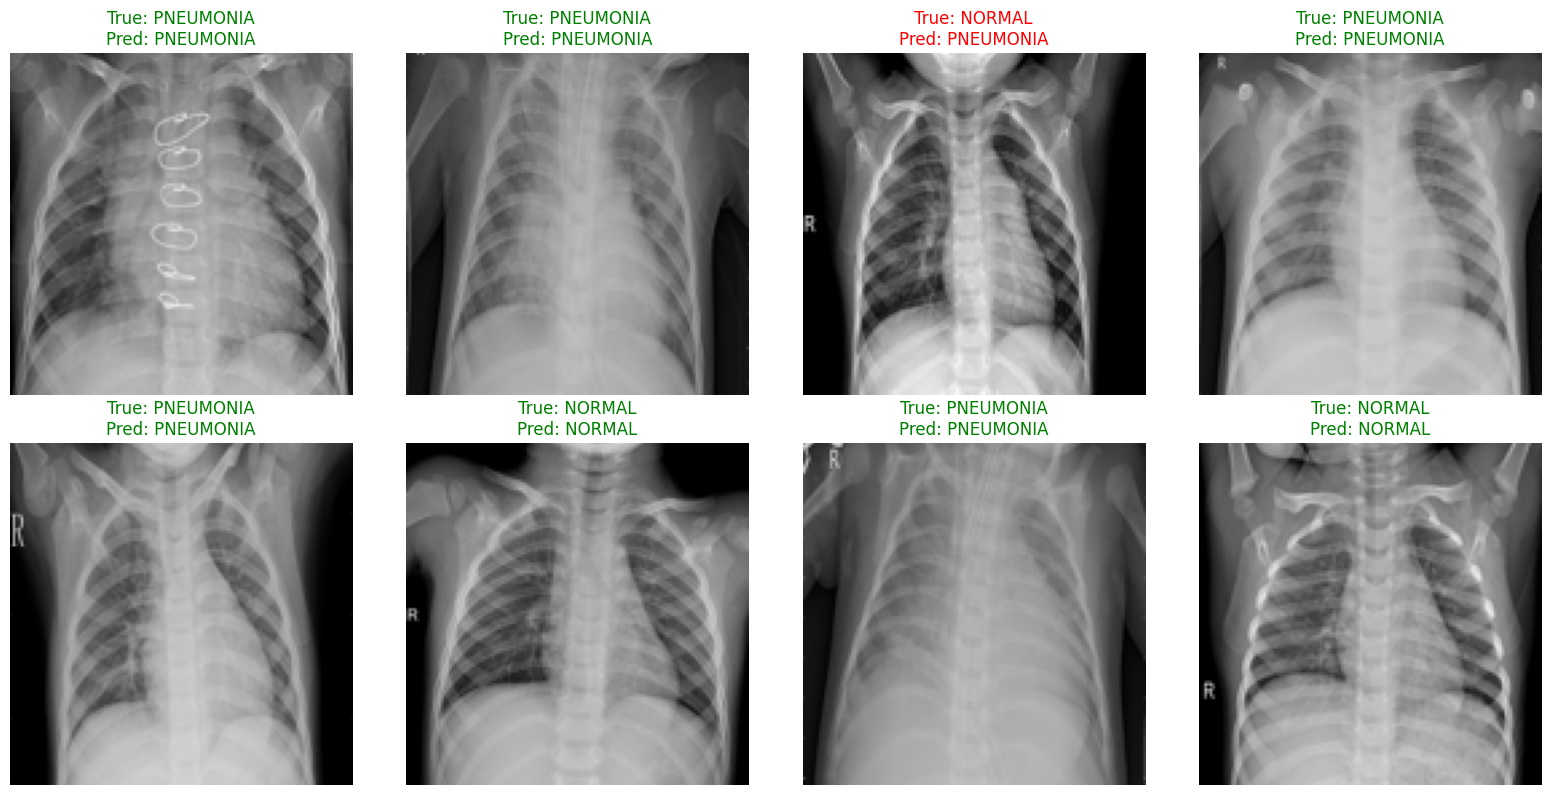

In [20]:
# Sample predictions (primary CNN)
y_true, y_pred, y_prob = predictions_store["primary_cnn"]
sample_idx = np.random.RandomState(SEED).choice(len(test_df), 8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, idx in zip(axes.ravel(), sample_idx):
    row = test_df.iloc[idx]
    img = Image.open(row["filepath"]).convert("RGB").resize(IMG_SIZE)
    ax.imshow(img)
    true_lbl = row["label"]
    pred_lbl = CLASSES[y_pred[idx]]
    ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}",
                 color=("green" if true_lbl == pred_lbl else "red"))
    ax.axis("off")
plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


## Section VI — Error Analysis and Discussion (Task 9)

At least 10 misclassified test images from the primary CNN, with prediction confidence.


Total misclassified on test set (primary CNN): 84 / 583


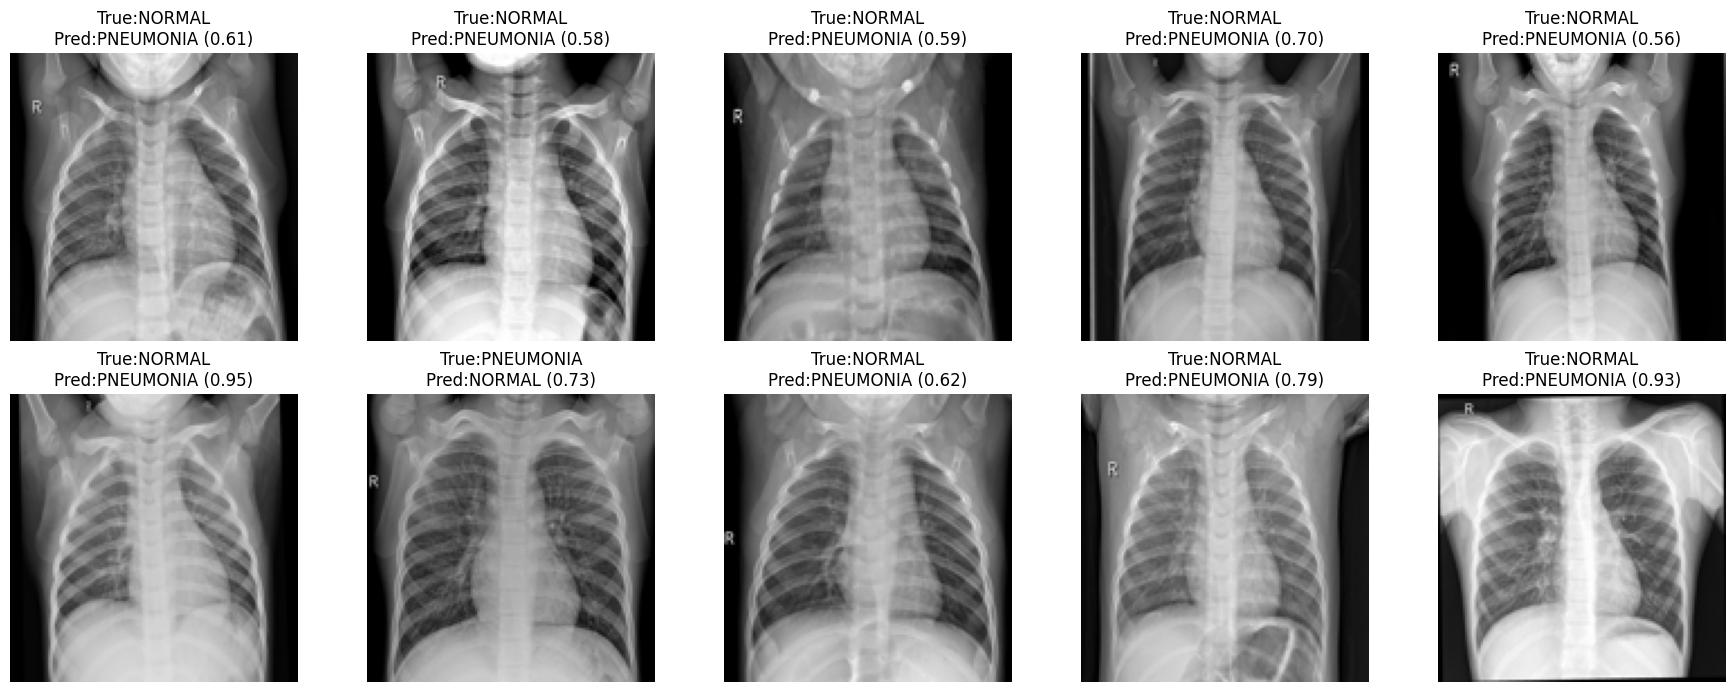

,filepath,true_label,predicted_label,confidence
0,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,PNEUMONIA,0.581628
1,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,PNEUMONIA,0.984793
2,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,PNEUMONIA,0.977781
3,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,PNEUMONIA,0.727451
4,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,PNEUMONIA,0.790476
5,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,PNEUMONIA,0.653399
6,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,PNEUMONIA,0.566054
7,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,PNEUMONIA,0.756305
8,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,PNEUMONIA,0.746958
9,/kaggle/input/datasets/paultimothymooney/chest...,NORMAL,PNEUMONIA,0.790761


In [21]:
y_true, y_pred, y_prob = predictions_store["primary_cnn"]
mis_idx = np.where(y_true != y_pred)[0]
print(f"Total misclassified on test set (primary CNN): {len(mis_idx)} / {len(y_true)}")

# The assignment asks for at least 10; if the model makes fewer than 10 errors,
# all available misclassified samples are shown and the exact count is reported.
n_show = min(10, len(mis_idx))
if n_show > 0:
    chosen = np.random.RandomState(SEED).choice(mis_idx, n_show, replace=False)

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.ravel()
    for ax in axes:
        ax.axis("off")

    for ax, idx in zip(axes, chosen):
        row = test_df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB").resize(IMG_SIZE)
        ax.imshow(img)
        true_lbl = row["label"]
        pred_lbl = CLASSES[y_pred[idx]]
        conf = y_prob[idx] if y_pred[idx] == 1 else 1 - y_prob[idx]
        ax.set_title(f"True:{true_lbl}\nPred:{pred_lbl} ({conf:.2f})")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("misclassified_examples.png", dpi=150, bbox_inches="tight")
    plt.show()

misclassified_table = pd.DataFrame({
    "filepath": test_df.iloc[mis_idx]["filepath"].values,
    "true_label": test_df.iloc[mis_idx]["label"].values,
    "predicted_label": [CLASSES[i] for i in y_pred[mis_idx]],
    "confidence": [
        y_prob[i] if y_pred[i] == 1 else 1-y_prob[i]
        for i in mis_idx
    ]
})
misclassified_table.to_csv("misclassified_images.csv", index=False)
display(misclassified_table.head(10))


**Write-up checklist for Section VI (fill in from your actual run's numbers/figures):**
- **Failure patterns** — look at the 10 images above: are false negatives concentrated on subtle/
  early-stage consolidations? Are false positives linked to imaging artifacts, positioning, or
  pediatric vs. adult chest shape differences (this dataset is pediatric)?
- **Overfitting vs. underfitting** — read this off the `*_curves.png` plots: a growing train/val
  loss gap flags overfitting; both curves plateauing high flags underfitting/undercapacity.
- **Generalization** — compare validation metrics (used for model selection) against held-out test
  metrics in `model_comparison.csv`; a large gap suggests the val set doesn't represent test well.
- **Effect of regularization** — compare `best_val_auc` across the L2/dropout settings in
  `grid_search_results.csv`.
- **Tuning observations** — summarize which hyperparameters moved `val_auc` the most.
- **Data volume** — describe the shape of the `data_volume_study.png` curve (diminishing returns?
  still climbing at 100%, suggesting more data would help?).
- **Future work** — e.g. Grad-CAM for interpretability, multi-class extension (COVID-19 dataset),
  ensembling the frozen/fine-tuned backbones, external validation on a different hospital's data.
